In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import sys
!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.3 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.3 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.3 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.3 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.3 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.3 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.3 MB 409.4 kB/s eta 0:00:18
   ----- ---------------------------------- 1.0/8.3 MB 409.4 kB/s eta 0:00:18
   ----- ---------------------------------- 1.0/8.3 MB 409.4 kB/s eta 0:00:18
   ----- ------------------

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [6]:
import sys
!{sys.executable} -m pip install openpyxl


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open

In [7]:
import openpyxl

In [13]:
import pandas as pd

df = pd.read_csv('Customer_Segmentation.csv', encoding='latin1')

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [15]:
df.shape

(541909, 8)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [17]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
(df.isnull().sum() / len(df)) * 100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [19]:
df.duplicated().sum()

np.int64(5268)

In [20]:
df = df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [23]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [24]:
df['InvoiceDate'].dtype

dtype('<M8[us]')

In [25]:
df['Quantity'].describe()

count    536641.000000
mean          9.620029
std         219.130156
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [27]:
df['UnitPrice'].describe()

count    536641.000000
mean          4.632656
std          97.233118
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [28]:
(df['Quantity'] < 0).sum()

np.int64(10587)

In [29]:
(df['UnitPrice'] <= 0).sum()

np.int64(2512)

In [30]:
df = df.drop_duplicates()

In [31]:
df = df.dropna(subset=['CustomerID'])

In [32]:
df = df[df['Quantity'] > 0]

In [33]:
df = df[df['UnitPrice'] > 0]

In [34]:
df.shape

(392692, 8)

In [35]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [36]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [37]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].describe()

,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [38]:
df['TotalAmount'].sum()

np.float64(8887208.894000001)

In [39]:
df['TotalAmount'].mean()

np.float64(22.631499735161402)

In [40]:
df['CustomerID'].nunique()

4338

In [41]:
df['InvoiceNo'].nunique()

18532

In [42]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [43]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [44]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [45]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [46]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [47]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [48]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalAmount           float64
dtype: object

In [51]:
df['Quantity'].describe()

count    392692.000000
mean         13.119702
std         180.492832
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [52]:
df['UnitPrice'].describe()

count    392692.000000
mean          3.125914
std          22.241836
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

In [53]:
(df['Quantity'] < 0).sum()

np.int64(0)

In [54]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

In [57]:
scaler = StandardScaler()

In [58]:
rfm_scaled = scaler.fit_transform(rfm_features)

In [59]:
rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

In [60]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [61]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

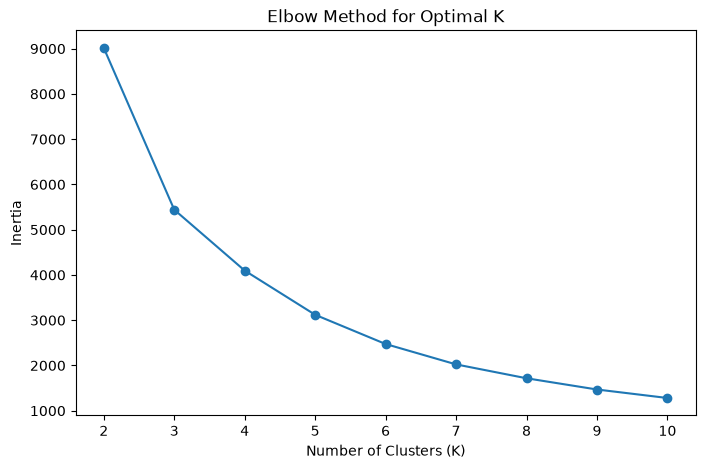

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [63]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

In [64]:
kmeans.fit(rfm_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 3)","[[-0.

In [65]:
rfm['Cluster'] = kmeans.labels_

In [66]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [67]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    3048
1    1063
2       8
3     213
4       6
Name: count, dtype: int64

In [68]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.918635,3.650262,1333.132908
1,248.469426,1.553151,478.648242
2,6.500000,120.500000,55099.491250
3,15.671362,21.286385,12813.941596
4,7.666667,42.833333,190808.536667


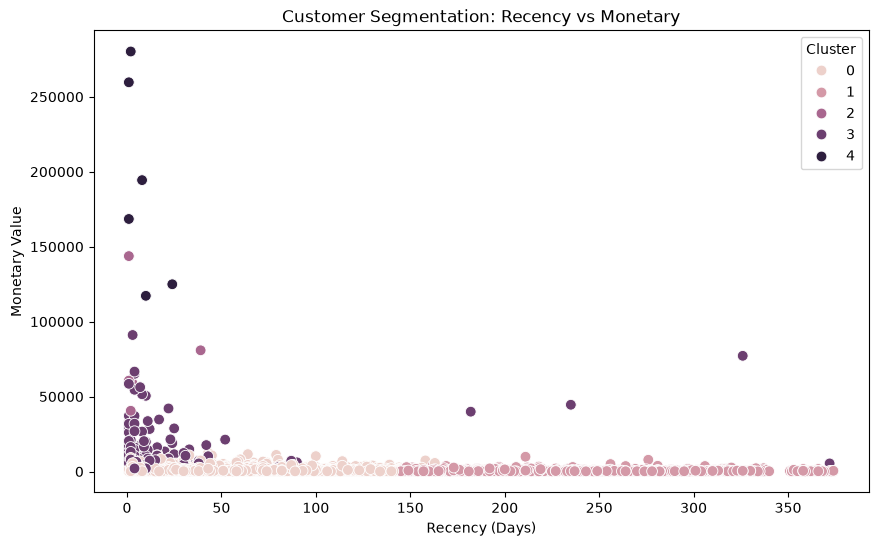

In [69]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    s=60
)

plt.title('Customer Segmentation: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.show()

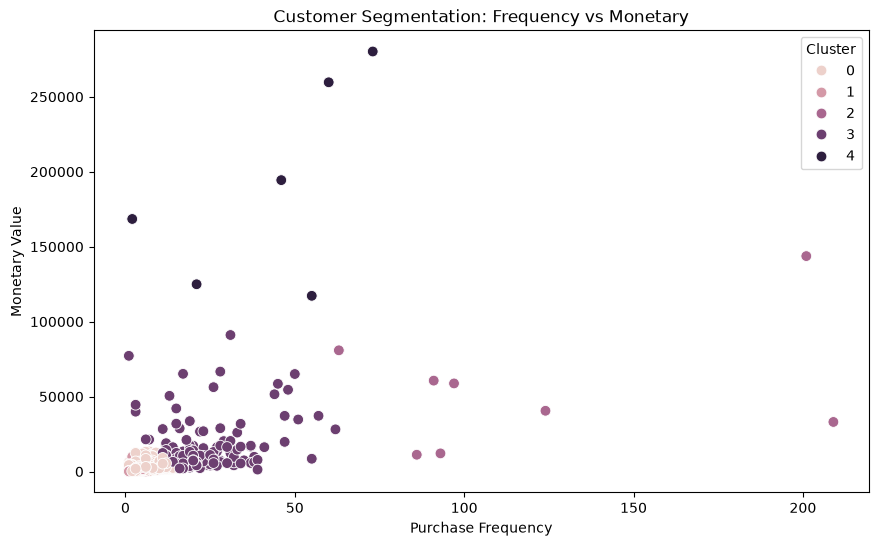

In [70]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    s=60
)

plt.title('Customer Segmentation: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.show()

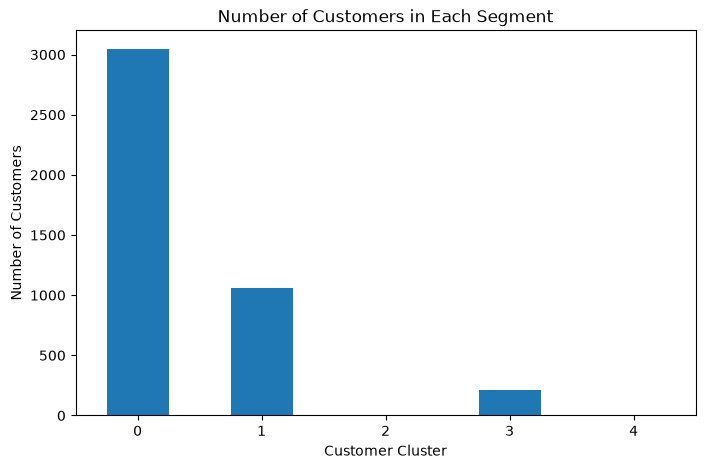

In [71]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

<Axes: xlabel='Recency', ylabel='Monetary'>

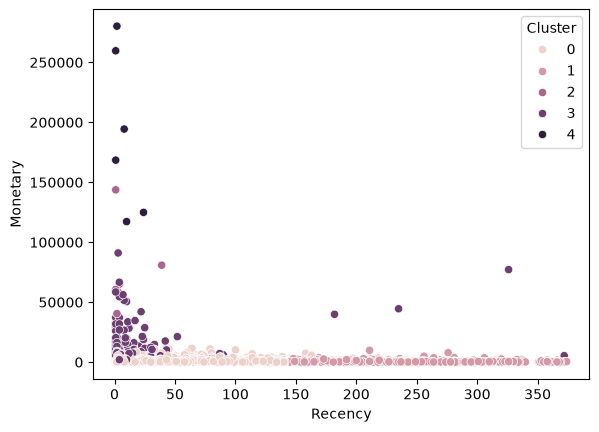

In [74]:
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster')

<Axes: xlabel='Frequency', ylabel='Monetary'>

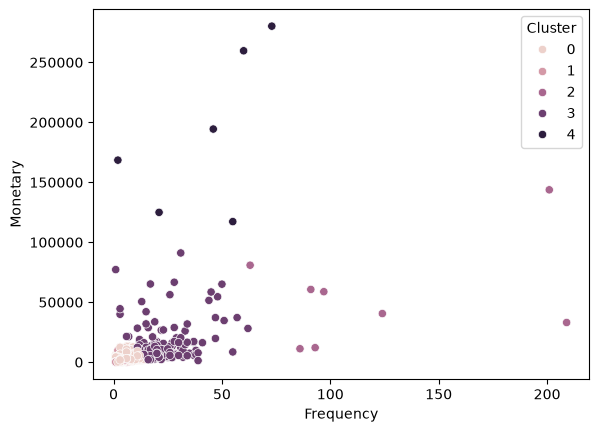

In [75]:
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster')

<Axes: xlabel='Cluster'>

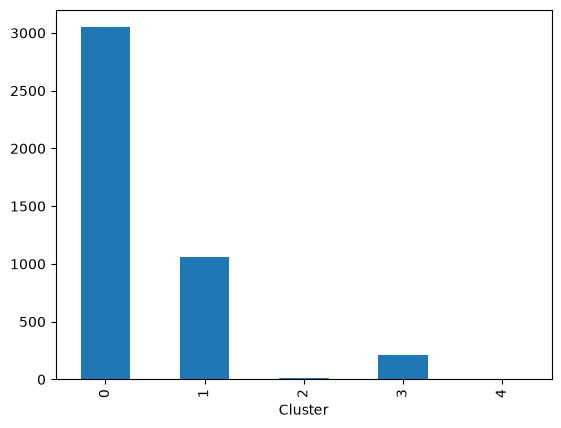

In [76]:
rfm['Cluster'].value_counts().sort_index().plot(kind='bar')

## Marketing Recommendations

### 1. Champions / Loyal High-Value Customers (Cluster 4)
- Introduce VIP loyalty programmes and exclusive rewards.
- Provide early access to new products and special promotions.
- Offer personalised recommendations based on their purchasing behaviour.
- Recognise and reward their loyalty to encourage long-term retention.

### 2. High Spenders / Frequent Buyers (Cluster 2)
- Use cross-selling and upselling strategies to increase spending per transaction.
- Introduce bundle offers and volume-based discounts.
- Provide personalised product recommendations.
- Encourage continued frequent purchasing through loyalty rewards.

### 3. Potential Loyal Customers (Cluster 3)
- Introduce loyalty points and rewards for repeat purchases.
- Send personalised promotions based on previous purchases.
- Offer limited-time discounts to encourage more frequent purchases.
- Gradually move these customers into higher-value customer segments.

### 4. At-Risk Customers (Cluster 0)
- Launch targeted win-back campaigns.
- Send personalised discounts or special offers.
- Recommend products based on their previous purchases.
- Use reminders and re-engagement messages to encourage them to return.

### 5. Low-Value / Inactive Customers (Cluster 1)
- Use low-cost reactivation campaigns to encourage a return purchase.
- Offer occasional incentives or targeted discounts.
- Test different re-engagement messages to identify customers who are likely to return.
- Avoid allocating excessive marketing resources to this segment unless engagement improves.

### Overall Marketing Strategy
The business should prioritise customer retention and revenue growth by investing more resources in Champions and High Spenders, developing Potential Loyal Customers, re-engaging At-Risk Customers, and using cost-effective campaigns for Low-Value/Inactive Customers.

## Business Insights

The customer segmentation analysis identified five distinct customer segments based on Recency, Frequency, and Monetary (RFM) behaviour.

### 1. Champions / Loyal High-Value Customers (Cluster 4)
This segment has a very low average recency of 7.67 days, a high purchase frequency of 42.83, and the highest average monetary value of £190,808.54. These customers are highly engaged, purchase frequently, and generate significant revenue for the business.

### 2. High Spenders / Frequent Buyers (Cluster 2)
Customers in this segment have an average recency of 6.50 days and the highest purchase frequency of 120.50, with an average monetary value of £55,099.49. They are highly active and represent an important revenue-generating customer group.

### 3. Potential Loyal Customers (Cluster 3)
This segment has an average recency of 15.67 days, a frequency of 21.29, and an average monetary value of £12,813.94. These customers are relatively active and show strong potential to become more loyal and valuable customers.

### 4. At-Risk Customers (Cluster 0)
Customers in this segment have an average recency of 43.92 days, a low purchase frequency of 3.65, and an average monetary value of £1,333.13. Their reduced purchasing activity suggests that they may be becoming less engaged with the business.

### 5. Low-Value / Inactive Customers (Cluster 1)
This segment has the highest average recency of 248.46 days, the lowest purchase frequency of 1.55, and the lowest average monetary value of £478.65. These customers are largely inactive and currently contribute relatively little revenue.

### Overall Business Insight
The analysis shows that customers have significantly different purchasing behaviours and value levels. The business should therefore avoid using a single marketing strategy for all customers. High-value and active customers should be prioritised for retention, while potential and at-risk customers require targeted engagement strategies to increase their value and prevent customer loss.